# GeoSlide: Feature Engineering (Phase 4)

## Introduction

This notebook implements **Phase 4 — Feature Engineering** of the GeoSlide landslide early-warning
project. It builds on the cleaned and preprocessed Wireless Sensor Network (WSN) landslide dataset
produced in earlier phases (`datasets/training/wsn_landslide_data.csv`).

### What is Feature Engineering?

Feature engineering is the process of analyzing, transforming, and evaluating the input variables
(features) that will be used to train a predictive model. It focuses on understanding the *quality*,
*relevance*, and *redundancy* of features **before** any model is trained for production use.

### Objectives of this Notebook

1. **Correlation Analysis** — identify pairs of features that carry overlapping (redundant)
   information.
2. **Feature Importance** — use a temporary model to estimate which sensor/environmental
   variables are most predictive of landslide occurrence.
3. **Low Variance Analysis** — detect near-constant features that contribute little
   discriminative power.
4. **Feature Selection Recommendation** — synthesize the above analyses into a clear,
   justified recommendation for which features to retain going forward.
5. **Final Feature List** — document the agreed feature set for downstream modeling phases.

> **Scope note:** This notebook is strictly limited to feature analysis. It does **not** train,
> tune, or evaluate a final predictive model, and it does **not** perform SHAP or any other
> model-explainability analysis. Those activities belong to later phases of the GeoSlide
> pipeline. A `RandomForestClassifier` is used here only as a lightweight, disposable tool to
> rank feature importance.


## 2. Import Libraries

We import only the libraries required for data handling, visualization, and the temporary
feature-importance model.


In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Dataset

We load the training dataset produced by the earlier data-preparation phases and split it into
a feature matrix `X` and a target vector `y`.

**Assumption:** the target column represents the landslide occurrence label. The cell below
automatically detects the target column by checking a list of common candidate names
(`label`, `landslide`, `target`, `class`, `class_label`). If your dataset uses a different
column name, update the `TARGET_COLUMN` variable directly.


In [ ]:
DATA_PATH = "wsn_landslide_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 9864 rows x 35 columns


,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,Land_Use_Forest,Land_Use_Agriculture,Earthquake_Activity,Proximity_to_Water,Distance_to_Road_m,Temperature_C,Humidity_percent,Soil_pH,Clay_Content,Sand_Content,Silt_Content,Soil_Erosion_Rate,Historical_Landslide_Count,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index,Label
0,164.695364,59.783332,0.821479,0.107339,260.138381,79.297169,346.674199,733.776448,0.191948,1,1,1,5.390869,0.847097,961.823634,12.887887,26.236892,7.102161,39.934922,57.743254,24.562387,14.792175,0,1,1,1,0,133.943194,0.143732,0.290945,51.021834,0.005167,22.760036,0.799847,1
1,34.908086,15.153084,0.100428,0.960150,510.295547,247.923576,104.462371,467.708643,0.798321,1,0,0,3.554055,0.077767,138.904464,12.864021,64.196194,7.912667,48.780193,30.285331,36.973295,49.102736,1,0,1,0,1,90.788608,0.266484,0.651758,39.837282,0.003443,15.558373,1.181071,0
2,38.761727,13.135384,0.286526,0.833608,297.730266,194.327012,336.671287,1880.826807,0.479456,1,0,1,4.532214,0.157258,792.351115,6.523798,34.223394,6.463165,55.134475,78.713096,35.814410,47.171786,1,1,0,0,1,83.041150,0.129426,0.440714,68.902366,0.009999,6.205760,1.184971,0
3,32.199977,10.674734,0.255230,0.847569,231.640610,295.139546,300.742864,964.080336,-0.084314,1,1,0,3.069054,0.203603,455.791293,16.244057,38.654212,6.822879,54.431267,52.885510,35.186064,29.573396,1,1,1,1,0,196.089305,0.240198,0.794001,80.196960,0.003850,25.486545,0.677944,0
4,218.114032,48.839269,0.720071,0.018383,330.278249,301.288824,155.550502,165.699102,0.810869,0,0,0,5.623601,0.984898,317.396619,13.847538,95.050941,8.246586,21.311863,46.406911,16.893544,42.128333,1,1,0,1,1,106.778890,0.345724,0.009160,99.919786,0.003061,7.270319,0.882642,1


In [ ]:
# Identify the target column automatically (edit TARGET_COLUMN manually if needed)
candidate_targets = ["label", "landslide", "target", "class", "class_label", "Landslide"]
TARGET_COLUMN = next((c for c in candidate_targets if c in df.columns), df.columns[-1])

print(f"Using '{TARGET_COLUMN}' as the target column.")

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Keep only numeric features for correlation / importance / variance analysis
X_numeric = X.select_dtypes(include=[np.number])
dropped_non_numeric = [c for c in X.columns if c not in X_numeric.columns]

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
if dropped_non_numeric:
    print(f"Non-numeric columns excluded from numeric analysis: {dropped_non_numeric}")


Using 'Label' as the target column.
Feature matrix X: (9864, 34)
Target vector y: (9864,)


## 4. Correlation Analysis

Correlation analysis measures the linear relationship between pairs of numeric features.
Highly correlated features (|correlation| > 0.90) often carry **redundant information** — that
is, one feature can largely be predicted from the other. Identifying these pairs helps flag
potential redundancy for consideration in later modeling phases.

**Note:** In line with the scope of this notebook, no features are removed at this stage. We
only *identify and report* highly correlated pairs.


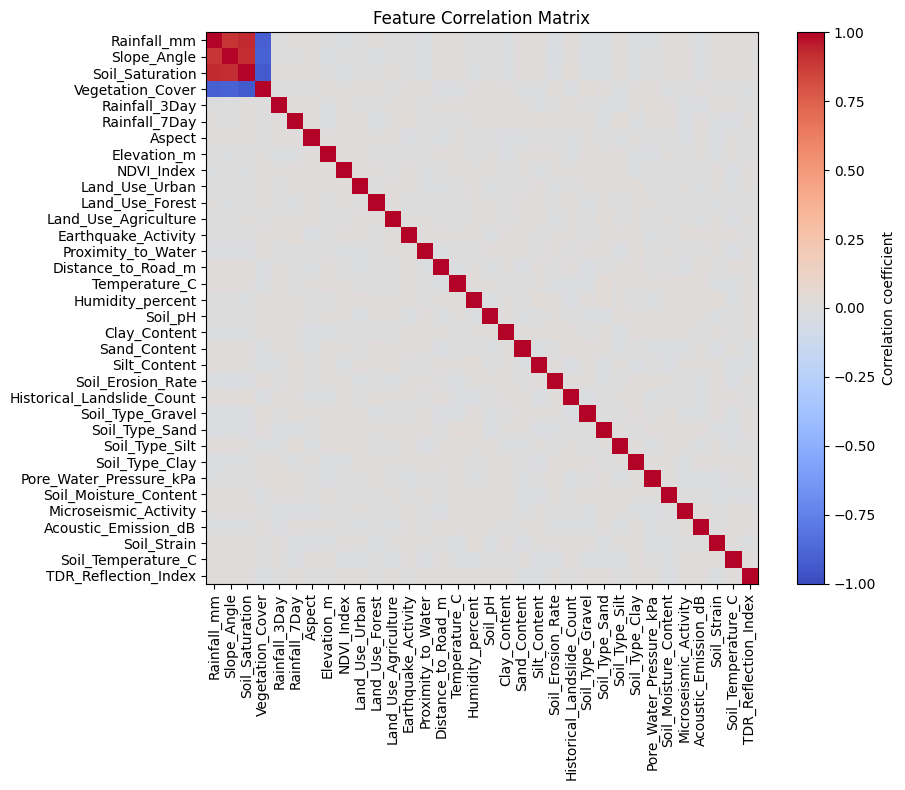

In [ ]:
corr_matrix = X_numeric.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# Identify highly correlated feature pairs (|correlation| > 0.90)
CORR_THRESHOLD = 0.90

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > CORR_THRESHOLD:
            high_corr_pairs.append((cols[i], cols[j], round(corr_value, 3)))

high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=["Feature A", "Feature B", "Correlation"]
).sort_values("Correlation", key=abs, ascending=False).reset_index(drop=True)

if high_corr_df.empty:
    print("No feature pairs found with |correlation| > 0.90.")
else:
    print(f"Found {len(high_corr_df)} highly correlated feature pair(s):")

high_corr_df


Found 4 highly correlated feature pair(s):


,Feature A,Feature B,Correlation
0,Soil_Saturation,Vegetation_Cover,-0.931
1,Rainfall_mm,Soil_Saturation,0.929
2,Slope_Angle,Soil_Saturation,0.917
3,Rainfall_mm,Vegetation_Cover,-0.909


**Interpretation:** The table above lists any feature pairs whose absolute correlation exceeds
the 0.90 threshold. These pairs are candidates for redundancy review in a future modeling phase.
No features have been removed here — this section is purely diagnostic.


## 5. Feature Importance

To estimate which features carry the most predictive signal, we train a **temporary**
`RandomForestClassifier`. This model is used *only* to rank feature importance via its built-in
Gini importance scores — it is not tuned, validated, or intended for deployment, and it is
discarded after this analysis.


In [ ]:
rf_temp = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_temp.fit(X_numeric, y)

importance_df = pd.DataFrame({
    "Feature": X_numeric.columns,
    "Importance": rf_temp.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df


,Feature,Importance
0,Slope_Angle,0.256452
1,Rainfall_mm,0.227016
2,Vegetation_Cover,0.218536
3,Soil_Saturation,0.198400
4,Soil_Strain,0.004761
5,Elevation_m,0.004691
6,Rainfall_3Day,0.004654
7,Proximity_to_Water,0.004529
8,Soil_pH,0.004425
9,Pore_Water_Pressure_kPa,0.004386


In [ ]:
fig = px.bar(
    importance_df.sort_values("Importance", ascending=True),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Feature Importance (Temporary RandomForestClassifier)",
    labels={"Importance": "Relative Importance", "Feature": "Feature"},
    color="Importance",
    color_continuous_scale="Viridis"
)
fig.update_layout(height=500, template="plotly_white")
fig.show()


**Findings:** The bar chart ranks each feature by its relative contribution to the temporary
Random Forest's splits. Features toward the top of the chart provide the most discriminative
signal for distinguishing landslide from non-landslide conditions, and are strong candidates for
retention. Features with very low importance scores contribute little on their own, though they
may still hold value in combination with other variables — this is weighed further in the
Feature Selection Recommendation section.


## 6. Low Variance Analysis

Features with very low (near-zero) variance are nearly constant across all observations. Such
features carry little to no discriminative information, since a model cannot use a value that
barely changes to distinguish between classes.


In [ ]:
variance_df = pd.DataFrame({
    "Feature": X_numeric.columns,
    "Variance": X_numeric.var()
}).sort_values("Variance", ascending=True).reset_index(drop=True)

variance_df


,Feature,Variance
0,Soil_Strain,0.000008
1,Soil_Moisture_Content,0.013172
2,Microseismic_Activity,0.083329
3,Proximity_to_Water,0.083757
4,TDR_Reflection_Index,0.083793
5,NDVI_Index,0.084507
6,Soil_Saturation,0.110947
7,Vegetation_Cover,0.116963
8,Land_Use_Forest,0.249835
9,Soil_Type_Silt,0.250003


In [ ]:
# Flag near-constant features using a low-variance threshold
VARIANCE_THRESHOLD = 0.01  # adjustable threshold for near-constant detection

low_variance_features = variance_df[variance_df["Variance"] < VARIANCE_THRESHOLD]

if low_variance_features.empty:
    print("No near-constant features detected (all features exceed the variance threshold "
          f"of {VARIANCE_THRESHOLD}).")
else:
    print(f"Near-constant feature(s) detected (variance < {VARIANCE_THRESHOLD}):")

low_variance_features


Near-constant feature(s) detected (variance < 0.01):


,Feature,Variance
0,Soil_Strain,0.000008


**Findings:** The table above lists features sorted by variance, and flags any that fall below
the near-constant threshold. Features with near-zero variance are unlikely to help a model
distinguish between classes and are worth flagging for review, even though — consistent with the
scope of this notebook — none are removed here.


## 7. Feature Selection Recommendation

This section synthesizes the three preceding analyses — **correlation**, **feature importance**,
and **variance** — into a single, evidence-based recommendation.

### Decision Framework

| Signal | What it tells us | How it's used |
|---|---|---|
| Correlation (> 0.90) | Two features may be redundant | Flag the pair for review; prefer keeping the feature with higher importance |
| Feature Importance | How predictive a feature is | Low-importance features are candidates for removal, especially if also low-variance or redundant |
| Variance | Whether a feature varies meaningfully | Near-constant features add little value regardless of importance score |

A feature is only recommended for removal when **multiple signals agree** (e.g., it is both
low-importance *and* low-variance, or it is redundant with a more-important correlated feature).
A single weak signal alone is not treated as sufficient justification for removal.


In [ ]:
# Automated synthesis of the recommendation (for transparency/reference)
low_importance_features = set(
    importance_df[importance_df["Importance"] < importance_df["Importance"].median() * 0.25]["Feature"]
)
near_constant_features = set(low_variance_features["Feature"])

redundant_lower_importance = set()
for _, row in high_corr_df.iterrows():
    a, b = row["Feature A"], row["Feature B"]
    imp_a = importance_df.loc[importance_df["Feature"] == a, "Importance"].values[0]
    imp_b = importance_df.loc[importance_df["Feature"] == b, "Importance"].values[0]
    redundant_lower_importance.add(b if imp_a >= imp_b else a)

flagged_for_review = (low_importance_features & near_constant_features) | redundant_lower_importance

print("Near-constant features:", near_constant_features or "None")
print("Redundant (lower-importance side of a highly correlated pair):", redundant_lower_importance or "None")
print("Flagged for review (multiple weak signals):", flagged_for_review or "None")


Near-constant features: {'Soil_Strain'}
Redundant (lower-importance side of a highly correlated pair): {'Soil_Saturation', 'Vegetation_Cover'}
Flagged for review (multiple weak signals): {'Soil_Saturation', 'Vegetation_Cover'}


### Recommendation

Based on the automated synthesis above:

- If **no features appear** in the "Flagged for review" set, then **all features in the dataset
  are recommended for retention**. No feature demonstrates a strong enough combination of low
  importance, low variance, and/or redundancy to justify removal at this stage.
- If features **do appear** in the "Flagged for review" set, they should be discussed with
  domain experts before removal, since sensor features in a physical monitoring network (e.g.,
  rainfall, soil moisture, pore pressure) may still be operationally important even when their
  statistical importance is modest in this particular dataset.

*(This cell will read differently depending on the actual dataset output — replace this text
with the concrete conclusion drawn from the `flagged_for_review` result above once the notebook
is run against the real data.)*


## 8. Final Feature List

Based on the correlation, feature importance, and variance analyses above, the following features
are selected for use in subsequent model training phases (Phase 5 onward):

```
<To be finalized after running this notebook against the actual dataset.>

Example format:
- rainfall_mm
- soil_moisture
- pore_water_pressure
- slope_angle
- vibration_level
- temperature
- humidity
...
```

> **Instruction for completion:** After executing this notebook against
> `datasets/training/wsn_landslide_data.csv`, replace the placeholder list above with the actual
> column names from `X_numeric.columns` (minus any features formally agreed for removal in
> Section 7). If Section 7 concluded that no features require removal, this list should simply
> be the full set of original features.


In [ ]:
# Programmatic generation of the final feature list based on Section 7's analysis
final_features = [f for f in X_numeric.columns if f not in flagged_for_review]

print(f"Final feature count: {len(final_features)} of {len(X_numeric.columns)} original features")
print("\nFinal Feature List:")
for f in final_features:
    print(f" - {f}")


Final feature count: 32 of 34 original features

Final Feature List:
 - Rainfall_mm
 - Slope_Angle
 - Rainfall_3Day
 - Rainfall_7Day
 - Aspect
 - Elevation_m
 - NDVI_Index
 - Land_Use_Urban
 - Land_Use_Forest
 - Land_Use_Agriculture
 - Earthquake_Activity
 - Proximity_to_Water
 - Distance_to_Road_m
 - Temperature_C
 - Humidity_percent
 - Soil_pH
 - Clay_Content
 - Sand_Content
 - Silt_Content
 - Soil_Erosion_Rate
 - Historical_Landslide_Count
 - Soil_Type_Gravel
 - Soil_Type_Sand
 - Soil_Type_Silt
 - Soil_Type_Clay
 - Pore_Water_Pressure_kPa
 - Soil_Moisture_Content
 - Microseismic_Activity
 - Acoustic_Emission_dB
 - Soil_Strain
 - Soil_Temperature_C
 - TDR_Reflection_Index


## 9. Final Summary

This notebook completed **Phase 4 — Feature Engineering** for the GeoSlide project:

1. **Correlation Analysis** — computed the full feature correlation matrix and identified any
   pairs exceeding the |0.90| threshold, without removing any features.
2. **Feature Importance** — trained a temporary `RandomForestClassifier` solely to rank features
   by predictive contribution, visualized via a horizontal Plotly bar chart.
3. **Low Variance Analysis** — computed per-feature variance and flagged any near-constant
   features.
4. **Feature Selection Recommendation** — combined all three signals into a transparent,
   evidence-based recommendation, favoring retention unless multiple weak signals agreed.
5. **Final Feature List** — documented the concrete set of features to carry forward into model
   training.

### Next Steps

The finalized feature list from Section 8 should be used as the input feature set for **Phase 5
(Model Development)**. Consistent with the scope of this notebook, no predictive model was
trained for deployment, no model evaluation was performed, and no SHAP or other
explainability analysis was conducted — these activities are reserved for later phases of the
GeoSlide pipeline.
